## Importando librerías

In [1]:
from keras.datasets import mnist
from keras import layers, models
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

## Nuestro set de datos

In [2]:
(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
train_data.shape

(60000, 28, 28)

In [4]:
test_data.shape

(10000, 28, 28)

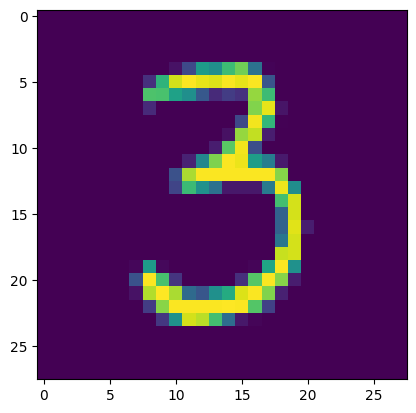

In [5]:
plt.imshow(train_data[50])
plt.show()

In [6]:
train_labels[85]

np.uint8(8)

## Creando un modelo de datos

In [7]:
model = models.Sequential()
model.add(layers.Dense(512, activation='relu', input_shape=(28*28,)))
model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

## Limpieza de datos

In [10]:
x_train = train_data.reshape((60000, 28*28))
x_train = x_train.astype('float32') / 255

x_test = test_data.reshape((10000, 28*28))
x_test = x_test.astype('float32') / 255

In [11]:
y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

In [12]:
train_labels[12]

np.uint8(3)

In [13]:
y_train[12]

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

## Entrenando el modelo

In [14]:
model.fit(x_train, y_train, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9242 - loss: 0.2643
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9686 - loss: 0.1073
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9785 - loss: 0.0709
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9844 - loss: 0.0522
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9889 - loss: 0.0383


## Evaluando sobre data de test

In [15]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9806 - loss: 0.0604


[0.06043035909533501, 0.9805999994277954]

## Matriz de Confusión

La matriz de confusión muestra cuántas veces la red predijo correctamente cada dígito
y en cuáles se confundió. Las filas son los **valores reales** y las columnas las **predicciones**.
La diagonal principal (verde) representa los aciertos.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


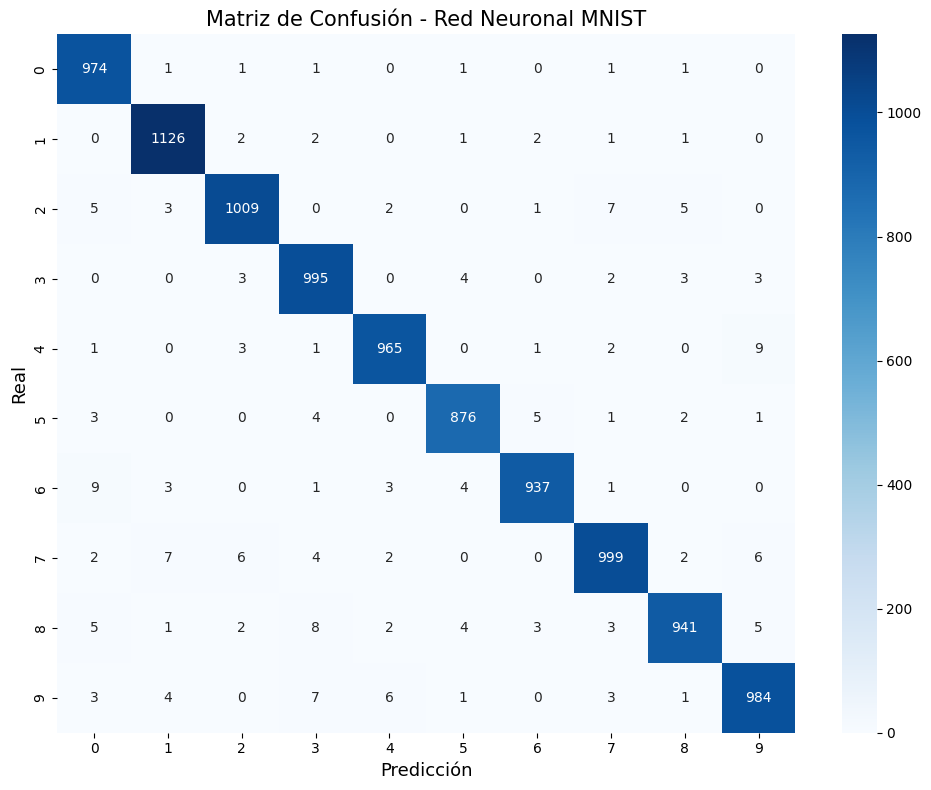


Precisión total: 9806/10000 = 98.06%


In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Obtener predicciones sobre el set de test
y_pred = model.predict(x_test)
y_pred_clases = np.argmax(y_pred, axis=1)   # clase predicha
y_real_clases = np.argmax(y_test, axis=1)   # clase real

# Calcular la matriz de confusión
cm = confusion_matrix(y_real_clases, y_pred_clases)

# Visualizar
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)
plt.xlabel('Predicción', fontsize=13)
plt.ylabel('Real', fontsize=13)
plt.title('Matriz de Confusión - Red Neuronal MNIST', fontsize=15)
plt.tight_layout()
plt.show()

# Precisión total
aciertos = np.trace(cm)  # suma de la diagonal
total = cm.sum()
print(f'\nPrecisión total: {aciertos}/{total} = {aciertos/total*100:.2f}%')

## Predicción con imagen


Sube una foto de un número del 0 al 9:


Saving WhatsApp Image 2026-04-21 at 11.45.33.jpeg to WhatsApp Image 2026-04-21 at 11.45.33 (1).jpeg

Procesando archivo "WhatsApp Image 2026-04-21 at 11.45.33 (1).jpeg"...


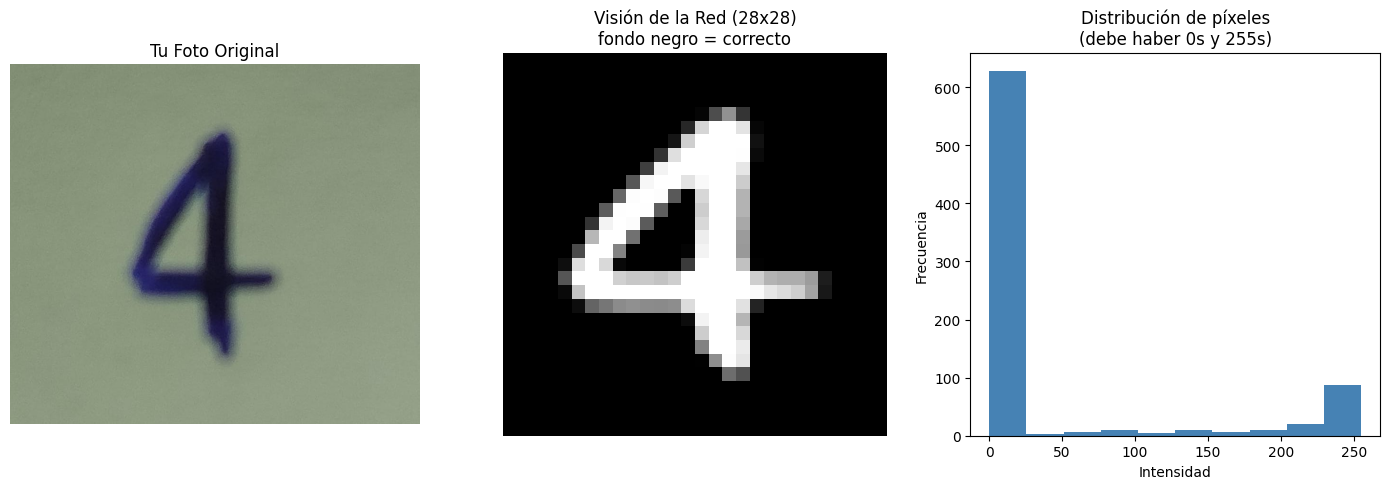

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

Probabilidades por dígito:
  0:  0.0%
  1:  0.0%
  2:  0.1%
  3:  0.0%
  4: █████████████████████████████ 99.9%
  5:  0.0%
  6:  0.0%
  7:  0.0%
  8:  0.0%
  9:  0.1%

---> ¡La red neuronal dice que el número es: 4! <---


In [21]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt
import numpy as np

def preprocesar_imagen(fn):
    """Convierte una foto de dígito manuscrito al formato MNIST (28x28, fondo negro, trazo blanco)."""

    # 1. Leer en escala de grises
    img = cv2.imread(fn, cv2.IMREAD_GRAYSCALE)

    # 2. Suavizar para reducir ruido del papel cuadriculado
    img_blur = cv2.GaussianBlur(img, (5, 5), 0)

    # 3. Umbral de Otsu: calcula automáticamente el mejor umbral global
    #    THRESH_BINARY_INV invierte (fondo negro, trazo blanco) en un solo paso
    _, img_bin = cv2.threshold(img_blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 4. Morfología: dilatar levemente para rellenar huecos en el trazo
    kernel = np.ones((2, 2), np.uint8)
    img_bin = cv2.dilate(img_bin, kernel, iterations=1)

    # 5. Recortar el bounding box del dígito y añadir margen
    coords = cv2.findNonZero(img_bin)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        margen = 10
        x1 = max(x - margen, 0)
        y1 = max(y - margen, 0)
        x2 = min(x + w + margen, img_bin.shape[1])
        y2 = min(y + h + margen, img_bin.shape[0])
        img_bin = img_bin[y1:y2, x1:x2]

    # 6. Redimensionar a 28x28 manteniendo proporción
    img_28 = cv2.resize(img_bin, (20, 20), interpolation=cv2.INTER_AREA)

    # 7. Centrar en lienzo 28x28 (como hace MNIST)
    lienzo = np.zeros((28, 28), dtype=np.uint8)
    lienzo[4:24, 4:24] = img_28

    return lienzo


print("Sube una foto de un número del 0 al 9:")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'\nProcesando archivo "{fn}"...')

    img_original = cv2.imread(fn)
    img_original_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

    img_procesada = preprocesar_imagen(fn)

    # Mostrar comparación
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))

    axes[0].imshow(img_original_rgb)
    axes[0].set_title("Tu Foto Original")
    axes[0].axis('off')

    axes[1].imshow(img_procesada, cmap='gray')
    axes[1].set_title("Visión de la Red (28x28)\nfondo negro = correcto")
    axes[1].axis('off')

    axes[2].hist(img_procesada.ravel(), bins=10, color='steelblue')
    axes[2].set_title("Distribución de píxeles\n(debe haber 0s y 255s)")
    axes[2].set_xlabel("Intensidad")
    axes[2].set_ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()

    # Predecir
    img_array = img_procesada.reshape((1, 28 * 28)).astype('float32') / 255
    prediccion = model.predict(img_array)
    clase_predicha = np.argmax(prediccion)

    print("\nProbabilidades por dígito:")
    for i, prob in enumerate(prediccion[0]):
        barra = '█' * int(prob * 30)
        print(f"  {i}: {barra} {prob*100:.1f}%")

    print(f"\n---> ¡La red neuronal dice que el número es: {clase_predicha}! <---")